In [48]:
import pandas as pd

df = pd.read_csv("data/dataset.csv", encoding="utf-8")
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13501 entries, 0 to 13500
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Unnamed: 0           13501 non-null  int64 
 1   Title                13496 non-null  object
 2   Ingredients          13501 non-null  object
 3   Instructions         13493 non-null  object
 4   Image_Name           13501 non-null  object
 5   Cleaned_Ingredients  13501 non-null  object
dtypes: int64(1), object(5)
memory usage: 633.0+ KB


# Preprocessing
Removing useless columns and rows with null values.
Removing also the corrisponding images to those rows.

In [49]:
import os

df.drop(columns=["Unnamed: 0"], inplace=True)
df_missing = df[df.isnull().any(axis=1)]
df.dropna(inplace=True)
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 13493 entries, 0 to 13500
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Title                13493 non-null  object
 1   Ingredients          13493 non-null  object
 2   Instructions         13493 non-null  object
 3   Image_Name           13493 non-null  object
 4   Cleaned_Ingredients  13493 non-null  object
dtypes: object(5)
memory usage: 632.5+ KB
None


In [50]:
# df.describe()

df = df[df['Image_Name'] != '#NAME?']
df = df[~df['Ingredients'].astype(str).isin(['[]', "['']"])]
df = df[~df['Cleaned_Ingredients'].astype(str).isin(['[]', "['']"])]
df = df.drop_duplicates(subset=['Title', 'Ingredients', 'Instructions'], keep='first')
print(f"Dimensioni finali del dataset: {df.shape}\n")
print(df.describe(include='O'))

Dimensioni finali del dataset: (13444, 5)

            Title                                        Ingredients  \
count       13444                                              13444   
unique      13267                                              13440   
top     French 75  ['1 cup (200 g) sugar', '3/4 cup (180 ml) wate...   
freq            5                                                  2   

                                             Instructions  \
count                                               13444   
unique                                              13428   
top     Place ingredients in blender in the order list...   
freq                                                    5   

                                               Image_Name  \
count                                               13444   
unique                                              13444   
top     miso-butter-roast-chicken-acorn-squash-panzanella   
freq                                          

In [51]:
df.describe()

,Title,Ingredients,Instructions,Image_Name,Cleaned_Ingredients
count,13444,13444,13444,13444,13444
unique,13267,13440,13428,13444,13440
top,French 75,"['1 cup (200 g) sugar', '3/4 cup (180 ml) wate...",Place ingredients in blender in the order list...,miso-butter-roast-chicken-acorn-squash-panzanella,"['1 cup (200 g) sugar', '3/4 cup (180 ml) wate..."
freq,5,2,5,1,2


## Image cleaning 

In [52]:
if df_missing.shape[0] > 0:
    print(f"Trovate {df_missing.shape[0]} righe con valori mancanti.")
    print("Rimuovendo le immagini corrispondenti alle righe con valori mancanti...")

image_folder = os.path.join("data", "Food Images")

for index, row in df_missing.iterrows():
    img_name = str(row["Image_Name"])
    
    if not img_name.endswith(".jpg"):
        img_name += ".jpg"
        
    image_path = os.path.join(image_folder, img_name)
    
    if os.path.exists(image_path):
        print(f"Rimuovo {image_path}...")
        os.remove(image_path)
    else:
        print(f"Immagine non trovata al percorso: {image_path}")

Trovate 8 righe con valori mancanti.
Rimuovendo le immagini corrispondenti alle righe con valori mancanti...
Immagine non trovata al percorso: data\Food Images\broccolini-cheddar-gratin-with-rye-breadcrumbs-51255550.jpg
Immagine non trovata al percorso: data\Food Images\smoked-salmon-with-egg-salad-and-green-beans-350313.jpg
Immagine non trovata al percorso: data\Food Images\royal-icing-240751.jpg
Immagine non trovata al percorso: data\Food Images\roasted-game-hens-with-caramelized-root-vegetables-and-dried-currant-sauce-236880.jpg
Immagine non trovata al percorso: data\Food Images\chicken-soup-with-rice-232605.jpg
Immagine non trovata al percorso: data\Food Images\double-lemon-bars-232572.jpg
Immagine non trovata al percorso: data\Food Images\pear-and-frangipane-crostata-with-raspberry-vinegar-glaze-231327.jpg
Immagine non trovata al percorso: data\Food Images\hazelnut-shortbread-sticks-231311.jpg


## Text cleaning (Test)

In [53]:
# take random text from the dataset
import random
random_index = random.randint(0, len(df) - 1)
# print ingredients and instructions in an extended format
print(f"Ingredients:\n{df.iloc[random_index]['Ingredients']}\n")
print(f"Instructions:\n{df.iloc[random_index]['Instructions']}\n")

print("Esempi di titoli:")
for i in range(10):
    print(f"{i+1}. {df.iloc[i]['Title']}")

Ingredients:
['olive oil', '4 cloves of garlic, peeled and very finely sliced', '2 big handfuls of pine nuts', 'A big handful of raisins', '12 salted anchovy fillets', '3 heaping tablespoons tomato purée', 'a large wineglass of red wine', '1 3/4 cups stale bread crumbs', '1 pound dried margherita pasta']

Instructions:
Heat a pan, add 6 tablespoons of olive oil, then add your garlic and fry slowly. As it begins to color, add the pine nuts, raisins, and anchovies and continue frying for 2 minutes, until the anchovies have melted. Add the tomato purée and the wine and stir in well. Leave to simmer on a medium heat for 3 minutes. The sauce should be quite thick, like tomato sauce, but if you think it needs thinning down, add a little water. Heat a little olive oil in a separate pan, add the bread crumbs and fry until toasted, crunchy, and golden. Leave to cool on paper towels. Meanwhile, cook your pasta in boiling salted water according to the package instructions. Drain and mix with the 

# Model - CLIP 
* We use the pre-trained CLIP model to convert all recipes titles into mathematical vectors (embeddings), then we process them in batches. 
* After generating and normalizing them, we concatenate the results into a single large tensor and save them to the recipe_embeddings.pt file. (precomputing)

In [ ]:
import torch
from transformers import CLIPProcessor, CLIPModel
from tqdm.notebook import tqdm 
DEVICE =  "cpu"

model_id = "openai/clip-vit-base-patch32"
model = CLIPModel.from_pretrained(model_id).to(DEVICE)
processor = CLIPProcessor.from_pretrained(model_id)

EMBEDDINGS_PATH = "data/recipe_embeddings.pt"

if os.path.exists(EMBEDDINGS_PATH):
    print(f"Embeddings già presenti in '{EMBEDDINGS_PATH}', caricamento...")
    saved_text_features = torch.load(EMBEDDINGS_PATH, map_location="cpu")
    print(f"Caricati {saved_text_features.shape[0]} vettori.")
else:
    titles = df["Title"].astype(str).tolist()
    batch_size = 128
    all_text_features = []

    model.eval()
    with torch.no_grad():
        for i in tqdm(range(0, len(titles), batch_size), desc="Calcolando embeddings"):
            batch_titles = titles[i:i+batch_size]
            
            inputs = processor(
                text=batch_titles,
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=77,
            ).to(DEVICE)

            text_outputs  = model.text_model(**inputs) #norm
            text_features = model.text_projection(text_outputs.pooler_output)

            #text_features = model.get_text_features(**inputs).pooler_output  # estrai le features testuali 
            #text_features = model.text_projection(text_features)  # proietta nello spazio CLIP condiviso

            # normalizzazione
            import torch.nn.functional as F
            text_features = F.normalize(text_features, p=2, dim=-1)
            all_text_features.append(text_features.cpu())
        
    saved_text_features = torch.cat(all_text_features, dim=0)
    torch.save(saved_text_features, EMBEDDINGS_PATH)
    print(f"Fine. Salvati {saved_text_features.shape[0]} vettori in '{EMBEDDINGS_PATH}'")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Calcolando embeddings:   0%|          | 0/106 [00:00<?, ?it/s]

Fine. Salvati 13444 vettori in 'data/recipe_embeddings.pt'


#### Description

* Given a food image path, returns the most similar recipe from the dataset.

* The image is encoded into a CLIP embedding and compared against all
pre-computed recipe title embeddings.
 
* It returns the best match as a dictionary object containing title, ingredients, instructions and
similarity score.

* Cosine similarity = measures the angle between two vectors

#### Association Image - Text (CLIP)

* The model is pre-trained to link an image with a corresponding text (description)
* When we submit a new image, it searches the closest result

* CLIP uses two separate encoders — one for images, one for text — that project
  inputs into a shared 512-dimensional vector space
* During training, matching (image, text) pairs are pushed close together while
  unrelated pairs are pushed apart 
* Recipe titles (from our DATASET) act as semantic labels: they are pre-encoded once and saved to disk.
  At inference time, only the image embedding is computed and compared against
  all pre-computed title embeddings via cosine similarity
* The recipe whose title vector is closest to the image vector is returned,
  along with its ingredients and instructions

In [ ]:
def identify_recipe(image_path: str) -> dict:
    image = Image.open(image_path).convert("RGB")
    inputs = processor(images=image, return_tensors="pt").to(DEVICE)

    model.eval() 
    with torch.no_grad():
        vision_outputs  = model.vision_model(**inputs) # estrai le features visive
        image_features  = model.visual_projection(vision_outputs.pooler_output) # proietta nello spazio CLIP condiviso
        image_features  = F.normalize(image_features, p=2, dim=-1).cpu() 

    # Cosine similarity, cioè l'angolo tra i vettori 
    similarities = (saved_text_features @ image_features.T).squeeze(1) # si computa la similarità tra l'immagine e tutte le ricette testuali
    best_idx = similarities.argmax().item() # si trova l'indice della ricetta più simile

    row = df.iloc[best_idx]
    return {
        "title":        row["Title"],
        "ingredients":  row["Cleaned_Ingredients"],
        "instructions": row["Instructions"],
        "similarity":   round(similarities[best_idx].item(), 3),
    }

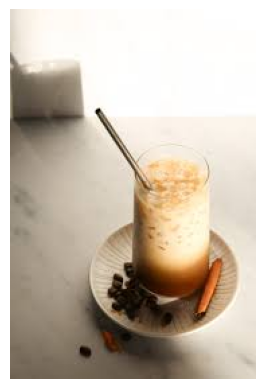

Piatto riconosciuto : Iced Coffee Shakerato
Similarity score   : 0.324

Ingredienti:
['1 1/2 ounces espresso or 3 ounces very strong coffee, cooled slightly', '1 tablespoon sweetened condensed milk', '1 1/2 teaspoons simple syrup']

Preparazione:
Combine espresso, sweetened condensed milk, and simple syrup in a cocktail shaker. Fill shaker with ice, cover, and shake vigorously until outside of shaker is very cold and mixture inside is very, very frothy, about 30 seconds.
Using a cocktail strainer or slotted spoon to hold back ice while allowing foam and some small ice chips to pass through, pour into an ice-filled glass.


In [59]:
# TEST

test_path = "data/TEST/iced_coffee.jpg"
result = identify_recipe(test_path)

from PIL import Image
import matplotlib.pyplot as plt

image = Image.open(test_path)
plt.imshow(image)
plt.axis('off')
plt.show()

print(f"Piatto riconosciuto : {result['title']}")
print(f"Similarity score   : {result['similarity']}")
print(f"\nIngredienti:\n{result['ingredients']}")
print(f"\nPreparazione:\n{result['instructions']}")